In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"C:\Users\vamsi\Downloads\AirPassengers.csv")
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [4]:
df['Month'].unique()

array(['1949-01', '1949-02', '1949-03', '1949-04', '1949-05', '1949-06',
       '1949-07', '1949-08', '1949-09', '1949-10', '1949-11', '1949-12',
       '1950-01', '1950-02', '1950-03', '1950-04', '1950-05', '1950-06',
       '1950-07', '1950-08', '1950-09', '1950-10', '1950-11', '1950-12',
       '1951-01', '1951-02', '1951-03', '1951-04', '1951-05', '1951-06',
       '1951-07', '1951-08', '1951-09', '1951-10', '1951-11', '1951-12',
       '1952-01', '1952-02', '1952-03', '1952-04', '1952-05', '1952-06',
       '1952-07', '1952-08', '1952-09', '1952-10', '1952-11', '1952-12',
       '1953-01', '1953-02', '1953-03', '1953-04', '1953-05', '1953-06',
       '1953-07', '1953-08', '1953-09', '1953-10', '1953-11', '1953-12',
       '1954-01', '1954-02', '1954-03', '1954-04', '1954-05', '1954-06',
       '1954-07', '1954-08', '1954-09', '1954-10', '1954-11', '1954-12',
       '1955-01', '1955-02', '1955-03', '1955-04', '1955-05', '1955-06',
       '1955-07', '1955-08', '1955-09', '1955-10', 

In [5]:
df['Month']=pd.to_datetime(df["Month"])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [7]:
df.isnull().sum()

Month          0
#Passengers    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.index=df['Month']

In [10]:
df.drop(columns='Month',inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [12]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


<Axes: xlabel='Month'>

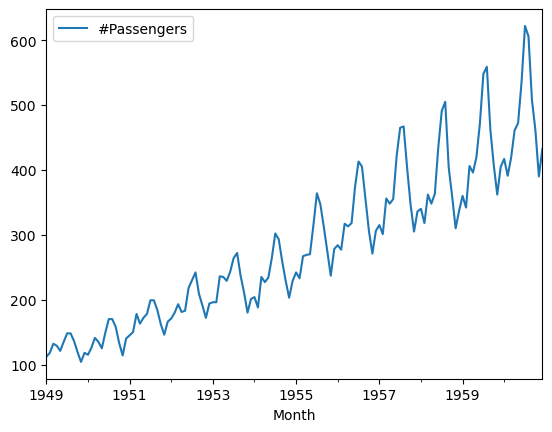

In [13]:
df.plot()

In [14]:
#Adfuller : test to check the stationarity of the series
#null hypo-> data is stationary
#alternate hypo-> data is not stationary

In [15]:
from statsmodels.tsa.stattools import adfuller

In [16]:
result=adfuller(df['#Passengers'])
result[1]  # this our p value 


0.991880243437641

In [17]:
p_val=result[1]

In [18]:
if (p_val<0.05):
    print('Data is stationary')
else :
    print('Data is not staionary')

Data is not staionary


In [19]:
#when data is not stationary, we perform De trend or transformation

In [20]:
rolling_mean=df.rolling(window=12).mean() #taking 12 month period as window
rolling_mean_detrend=df-rolling_mean
#subtract the rolling mean from actual passenger values : remove trend

In [21]:
rolling_mean_detrend.head(20)

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


<Axes: title={'center': 'original data'}, xlabel='Month'>

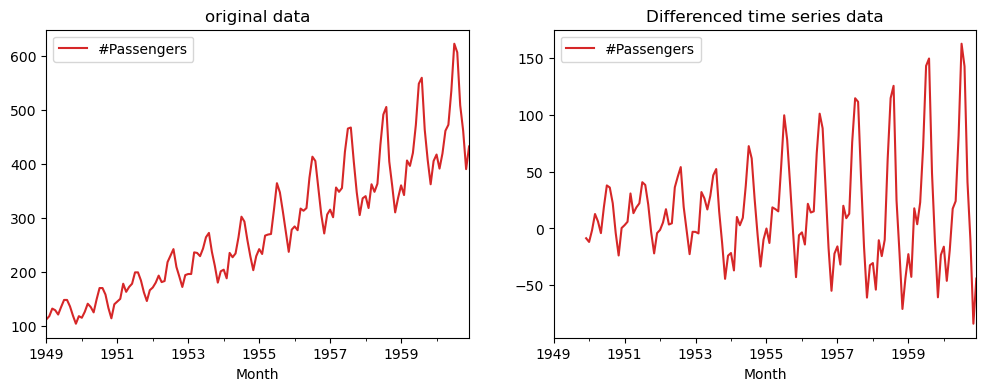

In [22]:
ax1=plt.subplot(1,2,2)
rolling_mean_detrend.plot(figsize=(12,4), color="tab:red", title='Differenced time series data', ax=ax1)
ax2=plt.subplot(1,2,1)
df.plot(figsize=(12,4),color='tab:red',title='original data', ax=ax2)

In [23]:
detrend_data=rolling_mean_detrend.dropna()  # smaller dataset

In [24]:
detrend_data

,#Passengers
Month,
1949-12-01,-8.666667
1950-01-01,-11.916667
1950-02-01,-1.583333
1950-03-01,12.666667
1950-04-01,6.166667
...,...
1960-08-01,142.666667
1960-09-01,40.916667
1960-10-01,-10.583333


In [25]:
result1=adfuller(detrend_data['#Passengers'])
result1[1]

0.022104139473878636

In [26]:
p_value3=result1[1]

In [27]:
if p_value3<0.05:
    print("We accept the Null Hypothesis - Data is stationary")
else:
    print("We reject the Null Hypothesis - Data is not stationary")

We accept the Null Hypothesis - Data is stationary


In [28]:
me=detrend_data.rolling(window=12).mean()
st=detrend_data.rolling(window=12).std()

Text(0.5, 1.0, 'Detrended Data with mean and std line')

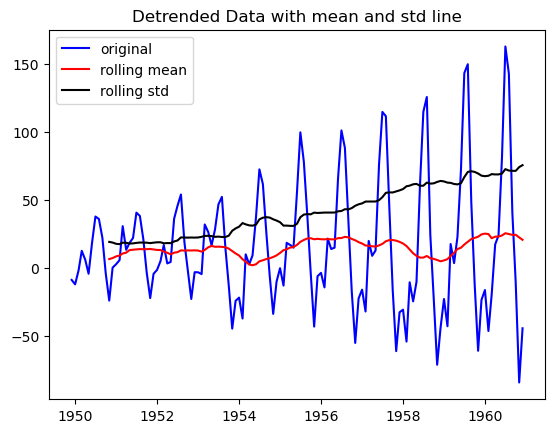

In [29]:
plt.plot(detrend_data,color='blue',label='original')
plt.plot(me,color='red',label='rolling mean')
plt.plot(st,color='black',label='rolling std')
plt.legend(loc='best')
plt.title('Detrended Data with mean and std line')

In [30]:
train=detrend_data[:120]['#Passengers']
test=detrend_data[120:]['#Passengers']

In [36]:
from statsmodels.tsa.arima.model import ARIMA

#order=>(p=AR,d=differencing,q=MA)
model=ARIMA(train,order=(1,0,2))

model_fit=model.fit()

C:\Users\vamsi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\vamsi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\vamsi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [37]:
detrend_data['Predict']=model_fit.predict(start=len(train),end=len(train)+len(test)-1) #testing data

C:\Users\vamsi\AppData\Local\Temp\ipykernel_11776\1179692947.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detrend_data['Predict']=model_fit.predict(start=len(train),end=len(train)+len(test)-1) #testing data


In [39]:
detrend_data.tail()

,#Passengers,Predict
Month,,
1960-08-01,142.666667,13.223010
1960-09-01,40.916667,13.280636
1960-10-01,-10.583333,13.306770
1960-11-01,-83.916667,13.318621
1960-12-01,-44.166667,13.323996


<Axes: xlabel='Month'>

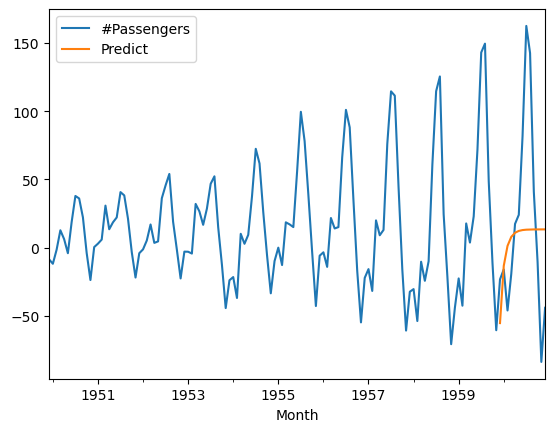

In [43]:
detrend_data[['#Passengers',"Predict"]].plot()

In [46]:
print(np.__version__)

1.24.3


In [47]:
 !pip install numpy==1.26.4 pmdarima==2.0.4
#run this command, restart session and then comment and import auto_arima

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.



  Obtaining dependency information for numpy==1.26.4 from https://files.pythonhosted.org/packages/3f/6b/5610004206cf7f8e7ad91c5a85a8c71b2f2f8051a0c0c4d5916b76d6cbb2/numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 162.5 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 461.8 kB/s eta 0:00:00
  Obtaining dependency information for pmdarima==2.0.4 from https://files.pythonhosted.org/packages/ac/f8/6c9364602b13f0dba129b53acd1344859690911a4d5021560d9fd6aa087f/pmdarima-2.0.4-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for Cython!=0.29.18,!=0.29.31,>=0.29 from https://files.pythonhosted.org/packages/6d/58/7d9ae7944bcd32e6f02d1a8d5d0c3875125227d050e235584127f2c64ffd/cython-3.1.4-cp311-cp311-win_amd64.whl.metadata
   -----------------------------

In [48]:
#AutoArima: finds the best model out of the time series model according to your dataset
from pmdarima import auto_arima

In [49]:
auto=auto_arima(detrend_data["#Passengers"])

In [50]:
auto.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  133
Model:               SARIMAX(3, 0, 2)   Log Likelihood                -612.905
Date:                Tue, 16 Sep 2025   AIC                           1239.810
Time:                        20:22:28   BIC                           1260.043
Sample:                    12-01-1949   HQIC                          1248.032
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      6.8579      1.701      4.033      0.000       3.525      10.191
ar.L1          0.8625      0.171      5.045      0.000       0.527       1.198
ar.L2          0.2071      0.236      0.878      0.380      -0.255       0.670
ar.L3         -0.5239      0.142     -3.683      0.000      -0.803      -0.245
ma.L1          0.0684      0.138      0.496      0.620      -0.202       0.338
ma.L2         -0.7564      0.091     -8.293      0.000      -0.935      -0.578
sigma2       577.4776     71.847      8.038      0.000     436.660     718.295
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 8.11
Prob(Q):                              0.89   Prob(JB):                         0.02
Heteroskedasticity (H):               6.21   Skew:                             0.56
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
#According to autoarima SARIMAX(3,0,2)is the best model for the given dataset

In [51]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [55]:
model=SARIMAX(train,order=(3,0,2),seasonal_order=(3,0,2,12))#every 12 month pattern is repeating
model=model.fit()

In [56]:
detrend_data['Predict']=model.predict(start=len(train),end=len(train)+len(test)-1)

<Axes: xlabel='Month'>

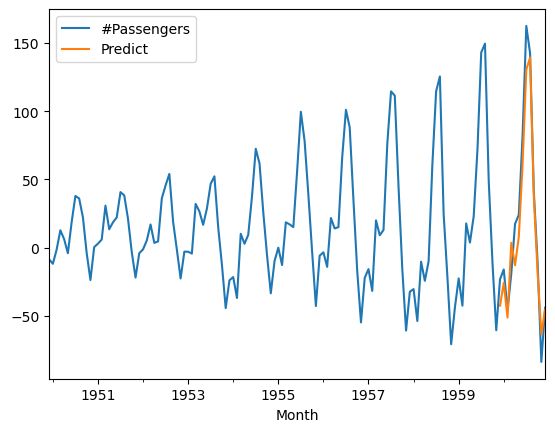

In [57]:
detrend_data[['#Passengers',"Predict"]].plot()

In [58]:
forecast=model.forecast(steps=48)#48=len(len(x_test)+future)

In [59]:
forecast

1959-12-01    -42.661570
1960-01-01    -25.981312
1960-02-01    -51.351882
1960-03-01      3.455732
1960-04-01    -12.973555
1960-05-01      7.786694
1960-06-01     60.728275
1960-07-01    130.582785
1960-08-01    139.380801
1960-09-01     37.189324
1960-10-01    -18.127287
1960-11-01    -63.539944
1960-12-01    -45.430529
1961-01-01    -24.976335
1961-02-01    -49.506158
1961-03-01      8.608298
1961-04-01     -6.236722
1961-05-01     14.500288
1961-06-01     61.084751
1961-07-01    131.685899
1961-08-01    139.449888
1961-09-01     40.446349
1961-10-01    -15.815495
1961-11-01    -61.652795
1961-12-01    -45.388251
1962-01-01    -27.519853
1962-02-01    -52.994283
1962-03-01      0.497792
1962-04-01    -14.675427
1962-05-01      7.720229
1962-06-01     58.376832
1962-07-01    126.525239
1962-08-01    136.027658
1962-09-01     35.795628
1962-10-01    -16.246248
1962-11-01    -58.888152
1962-12-01    -43.640357
1963-01-01    -23.238849
1963-02-01    -48.535254
1963-03-01      6.929116


<Axes: xlabel='Month'>

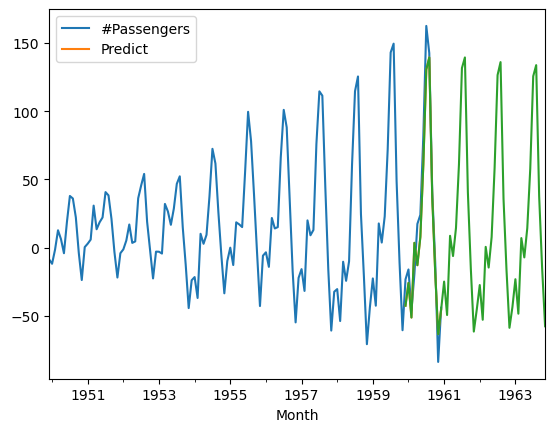

In [61]:
detrend_data.plot()
forecast.plot()